In [1]:
!pip install kaggle opencv-python-headless tensorflow scikit-learn matplotlib

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anthonya6983","key":"53b7f029c9ea84bfca3b683ba037967d"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/breast-histopathology-images

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.10G/3.10G [00:42<00:00, 78.0MB/s]



In [5]:
!unzip breast-histopathology-images.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1551_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1601_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1651_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1701_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1751_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1801_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1851_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1901_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1951_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y2001_class0.png  
  inflating: /content/data/IDC_regular_

In [6]:
import os
import shutil

source = "/content/data/IDC_regular_ps50_idx5"
destination = "/content/data/IDC_binary"

os.makedirs(os.path.join(destination, "0"), exist_ok=True)
os.makedirs(os.path.join(destination, "1"), exist_ok=True)

for patient in os.listdir(source):

    patient_path = os.path.join(source, patient)

    if not os.path.isdir(patient_path):
        continue

    for label in ["0", "1"]:

        label_path = os.path.join(patient_path, label)

        if os.path.exists(label_path):

            for image in os.listdir(label_path):

                shutil.copy(
                    os.path.join(label_path, image),
                    os.path.join(destination, label, image)
                )

print("Dataset organized successfully.")

Dataset organized successfully.


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [8]:
IMG_SIZE = (128,128)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_gen = datagen.flow_from_directory(
    "/content/data/IDC_binary",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "/content/data/IDC_binary",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 222020 images belonging to 2 classes.
Found 55504 images belonging to 2 classes.


In [9]:
print(train_gen.class_indices)

{'0': 0, '1': 1}


In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model = tf.keras.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

In [12]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [13]:
history = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=3

)

Epoch 1/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 336s 46ms/step - accuracy: 0.8440 - loss: 0.3648 - val_accuracy: 0.8114 - val_loss: 0.4168
Epoch 2/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 205s 30ms/step - accuracy: 0.8549 - loss: 0.3408 - val_accuracy: 0.8147 - val_loss: 0.4108
Epoch 3/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 199s 29ms/step - accuracy: 0.8583 - loss: 0.3331 - val_accuracy: 0.8285 - val_loss: 0.3941


In [14]:
loss, accuracy = model.evaluate(val_gen)

print("Loss:", loss)
print("Accuracy:", accuracy)

1735/1735 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.8285 - loss: 0.3941
Loss: 0.3941288888454437
Accuracy: 0.8285349011421204


In [15]:
val_gen.reset()

predictions = model.predict(val_gen)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = val_gen.classes

1735/1735 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step


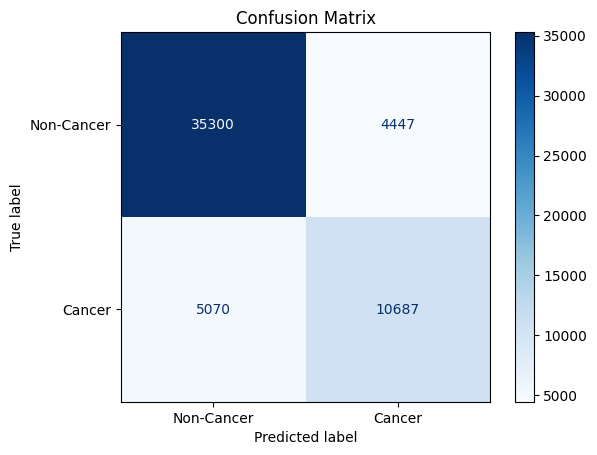

In [16]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Cancer","Cancer"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

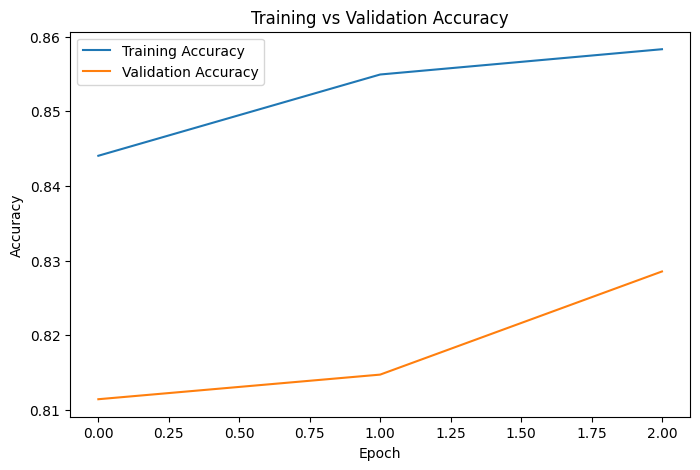

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

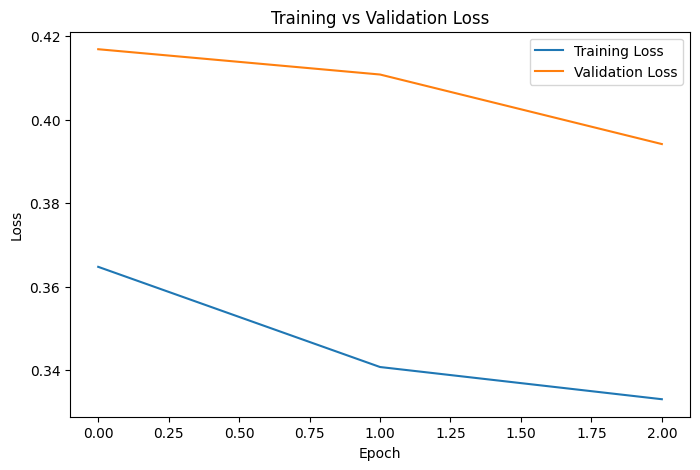

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

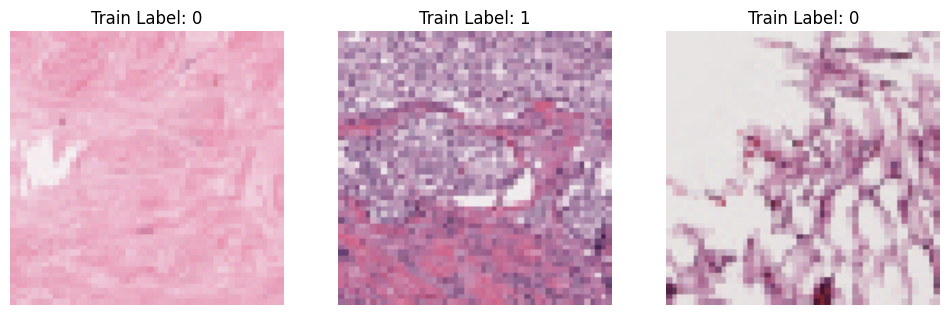

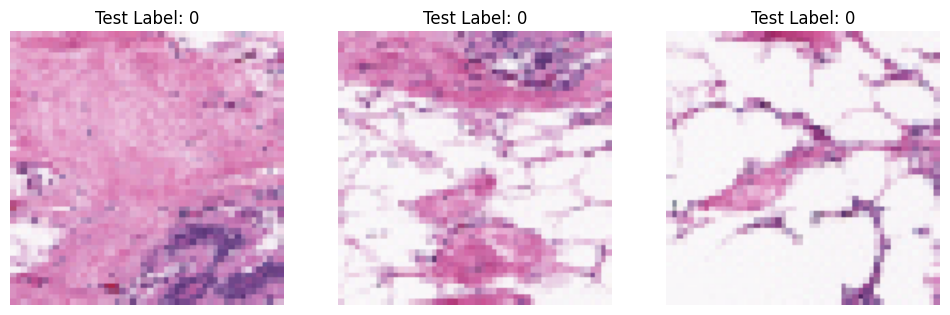

In [19]:
import matplotlib.pyplot as plt

# Get one batch from the training generator
train_images, train_labels = next(train_gen)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(train_images[i])
    plt.title(f"Train Label: {int(train_labels[i])}")
    plt.axis('off')
plt.show()


# Get one batch from the validation/test generator
val_images, val_labels = next(val_gen)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(val_images[i])
    plt.title(f"Test Label: {int(val_labels[i])}")
    plt.axis('off')
plt.show()

In [20]:
print(classification_report(

    true_classes,

    predicted_classes,

    target_names=["Non-Cancer","Cancer"]

))


              precision    recall  f1-score   support

  Non-Cancer       0.87      0.89      0.88     39747
      Cancer       0.71      0.68      0.69     15757

    accuracy                           0.83     55504
   macro avg       0.79      0.78      0.79     55504
weighted avg       0.83      0.83      0.83     55504

